# WHAT A DAY!

We got so much done - a Fronter RAG pipeline, a Random Forest model using transformer-based encodings, and an Ensemble model.

You can do better, for sure!

Tweak this, and try adding components into the ensemble, to beat my performance.

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Model saved! File size: 2.23 MB
1: Guess: $271.28 Truth: $374.41 Error: $103.13 SLE: 0.10 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $206.35 Truth: $225.11 Error: $18.76 SLE: 0.01 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $260.25 Truth: $61.68 Error: $198.57 SLE: 2.04 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $250.94 Truth: $599.99 Error: $349.05 SLE: 0.76 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $222.96 Truth: $16.99 Error: $205.97 SLE: 6.36 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $112.06 Truth: $31.99 Error: $80.07 SLE: 1.52 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $262.09 Truth: $101.79 Error: $160.30 SLE: 0.88 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $219.38 Truth: $289.00 Error: $69.62 SLE: 0.08 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $313.87 Truth: $635.86 Error: $321.99 SLE: 0.50 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $207

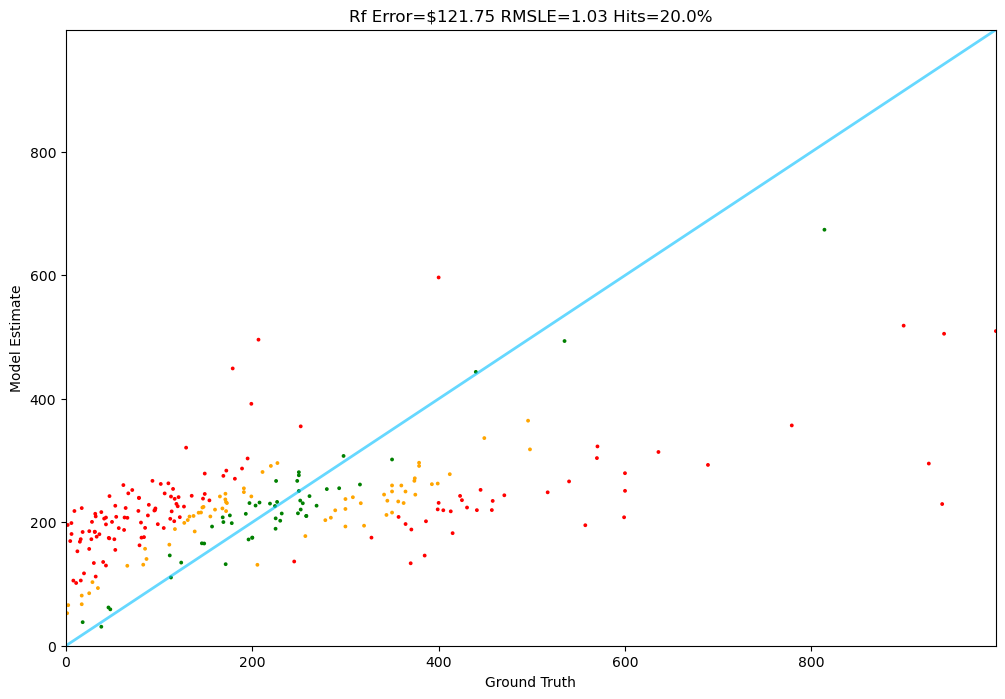

189.0
195.19
265.5398219318311


100%|████████████████████████████████████████████████████████████████████████████████| 250/250 [14:30<00:00,  3.48s/it]


Specialist: 0.48
Frontier: 0.24
RandomForest: -0.29
Min: 0.30
Max: 0.25
Intercept=22.96
1: Guess: $418.17 Truth: $374.41 Error: $43.76 SLE: 0.01 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $220.11 Truth: $225.11 Error: $5.00 SLE: 0.00 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $47.54 Truth: $61.68 Error: $14.14 SLE: 0.07 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $363.00 Truth: $599.99 Error: $236.99 SLE: 0.25 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $35.78 Truth: $16.99 Error: $18.79 SLE: 0.51 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $34.04 Truth: $31.99 Error: $2.05 SLE: 0.00 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $115.15 Truth: $101.79 Error: $13.36 SLE: 0.01 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $362.89 Truth: $289.00 Error: $73.89 SLE: 0.05 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $842.71 Truth: $635.86 Error: $206.85 SLE: 0.08 Item: Randall RG75DG

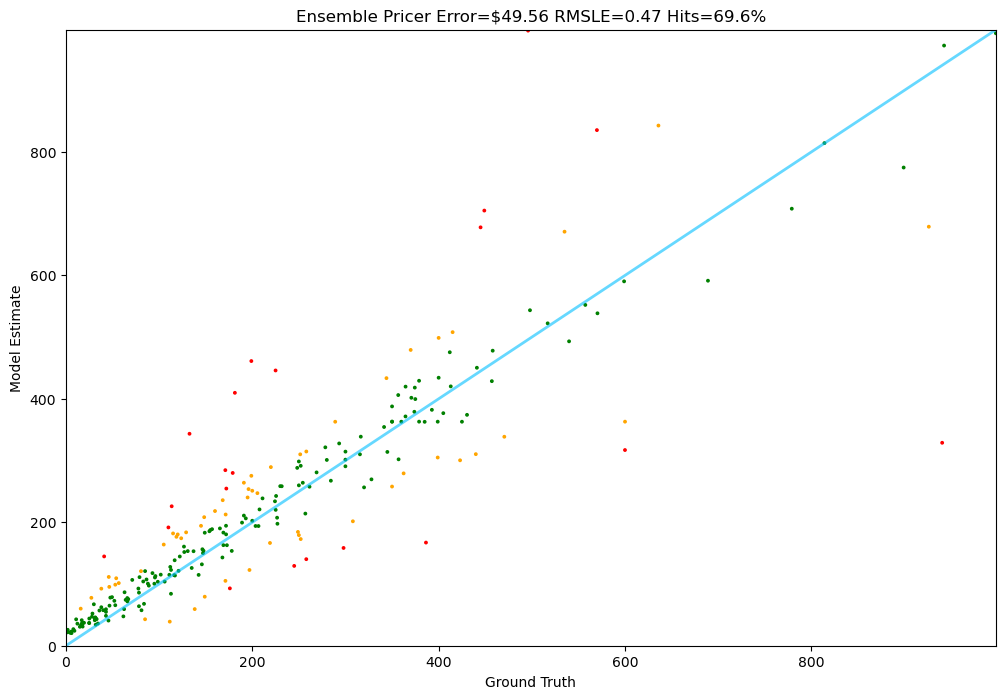

In [2]:
# imports

import os
import re
import math
import json
from tqdm import tqdm
import random
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import pickle
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import chromadb
from items import Item
from testing import Tester
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# CONSTANTS

QUESTION = "How much does this cost to the nearest dollar?\n\n"
DB = "products_vectorstore"

# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

# Load test data

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)

# Connect to Chroma

client = chromadb.PersistentClient(path=DB)
collection = client.get_or_create_collection('products')

result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'], dtype=np.float32)  # Optimize: float32
documents = result['documents']
prices = [metadata['price'] for metadata in result['metadatas']]

# ✅ Optimized Random Forest Model

rf_model = RandomForestRegressor(
    n_estimators=50,       # Smaller number of trees
    max_depth=10,          # Limit tree depth
    random_state=42,
    n_jobs=-1
)
rf_model.fit(vectors, prices)

# Save with compression

joblib.dump(rf_model, 'random_forest_model.pkl', compress=3)

# Check file size

import os
size_mb = os.path.getsize('random_forest_model.pkl') / 1024 / 1024
print(f"✅ Model saved! File size: {size_mb:.2f} MB")

if size_mb > 500:
    print("⚠️ Warning: Model is still large. Consider reducing estimators or depth further.")

# Load it back

rf_model = joblib.load('random_forest_model.pkl')

# Agents

from agents.specialist_agent import SpecialistAgent
from agents.frontier_agent import FrontierAgent
from agents.random_forest_agent import RandomForestAgent

specialist = SpecialistAgent()
frontier = FrontierAgent(collection)
random_forest = RandomForestAgent()

# Prediction helpers

def description(item):
    return item.prompt.split("to the nearest dollar?\n\n")[1].split("\n\nPrice is $")[0]

def rf(item):
    return random_forest.price(description(item))

Tester.test(rf, test)

# Manual test
product = "Quadcast HyperX condenser mic for high quality audio for podcasting"
print(specialist.price(product))
print(frontier.price(product))
print(random_forest.price(product))

# Run ensemble input collection

specialists = []
frontiers = []
random_forests = []
prices = []

for item in tqdm(test[1000:1250]):
    text = description(item)
    specialists.append(specialist.price(text))
    frontiers.append(frontier.price(text))
    random_forests.append(random_forest.price(text))
    prices.append(item.price)

mins = [min(s, f, r) for s, f, r in zip(specialists, frontiers, random_forests)]
maxes = [max(s, f, r) for s, f, r in zip(specialists, frontiers, random_forests)]

X = pd.DataFrame({
    'Specialist': specialists,
    'Frontier': frontiers,
    'RandomForest': random_forests,
    'Min': mins,
    'Max': maxes,
})

y = pd.Series(prices)

# Train Ensemble Linear Regression

np.random.seed(42)
lr = LinearRegression()
lr.fit(X, y)

# Print Coefficients

feature_columns = X.columns.tolist()
for feature, coef in zip(feature_columns, lr.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept={lr.intercept_:.2f}")

# Save Ensemble Model

joblib.dump(lr, 'ensemble_model.pkl')

# Test Ensemble Agent

from agents.ensemble_agent import EnsembleAgent
ensemble = EnsembleAgent(collection)

ensemble.price(product)

def ensemble_pricer(item):
    return max(0, ensemble.price(description(item)))

Tester.test(ensemble_pricer, test)
